# 🔍 04 — Explicabilité avec SHAP
**Objectif** : Comprendre l'impact de chaque variable sur les prédictions du modèle XGBoost.

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Chargement
df_enc = pd.read_csv(r'C:\Users\imene\churn-prediction\data\telco_encoded.csv')
model = joblib.load(r'C:\Users\imene\churn-prediction\src\xgb_churn_model.pkl')
scaler = joblib.load(r'C:\Users\imene\churn-prediction\src\scaler.pkl')

X = df_enc.drop('Churn', axis=1)
y = df_enc['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
X_test_sc = scaler.transform(X_test)

print("✅ Modèle et données chargés")

c:\Users\imene\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Modèle et données chargés


## 1. Calcul des valeurs SHAP

In [2]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sc)
print(f"SHAP values shape : {shap_values.shape}")

SHAP values shape : (1409, 34)


## 2. Top 10 features — importance globale

In [13]:
shap_df = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False).head(10)

fig = px.bar(
    shap_df, x='importance', y='feature',
    orientation='h',
    title='Top 10 features SHAP — Impact moyen sur le churn',
    color='importance',
    color_continuous_scale='Reds'
)
fig.update_layout( yaxis={'categoryorder': 'total ascending'},coloraxis_showscale=False)
fig.show()
fig.write_html(r'C:\Users\imene\churn-prediction\outputs\shap_importance.html')
print("✅ shap_importance.html exporté")

✅ shap_importance.html exporté


## 3. SHAP Beeswarm — distribution des impacts

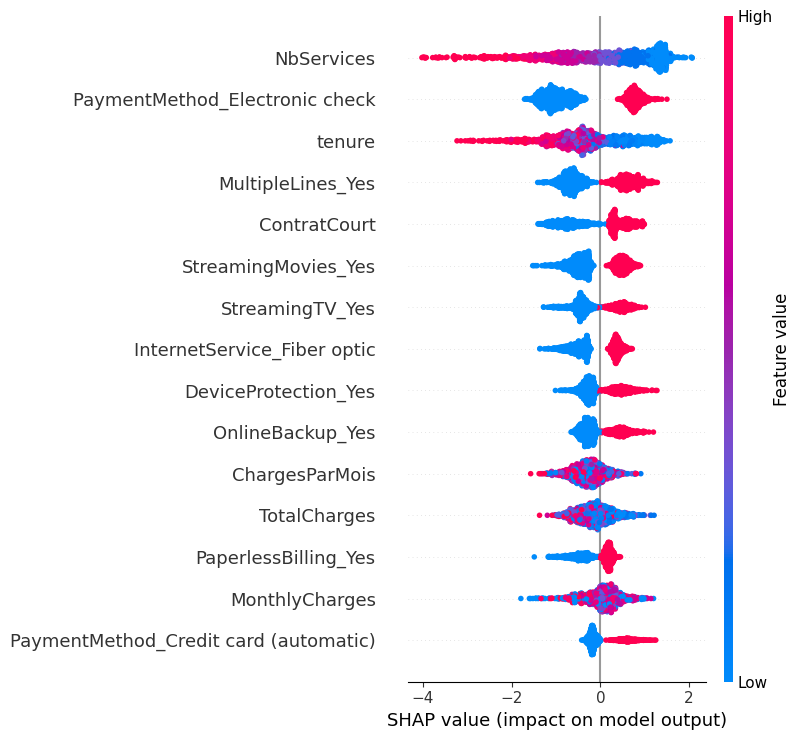

In [4]:
# Graphique natif SHAP (matplotlib)
shap.summary_plot(shap_values, X_test_sc, feature_names=list(X.columns), max_display=15)

## 4. Explication d'un client individuel

Probabilité de churn du client #0 : 0.4%


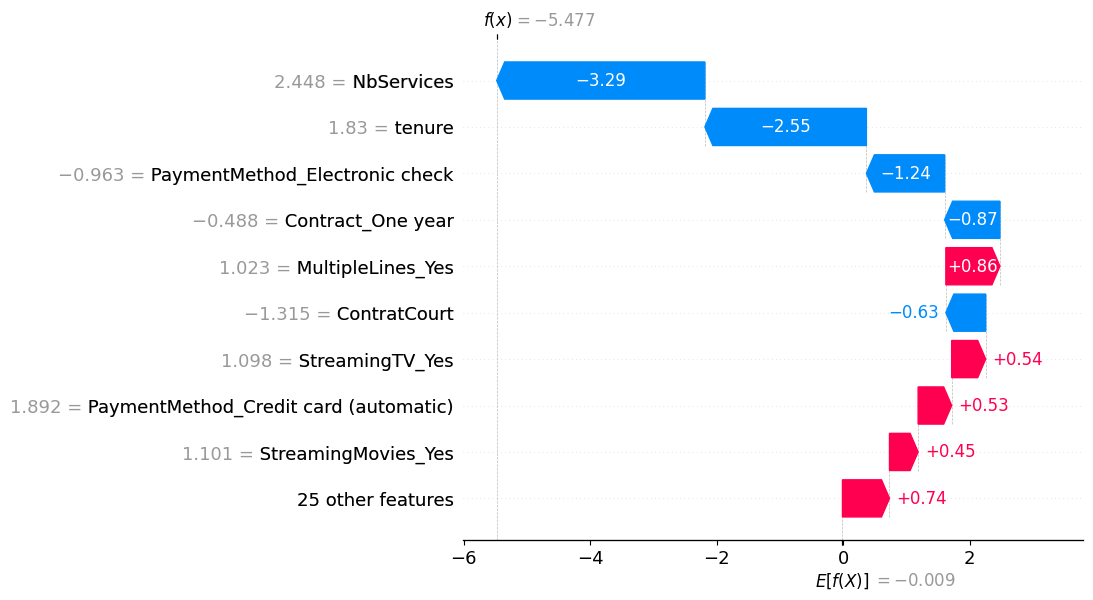

In [23]:
# Exemple : client à risque élevé
idx = 0  # Changer l'index pour explorer d'autres clients
client = X_test.iloc[[idx]]
client_sc = scaler.transform(client)

proba = model.predict_proba(client_sc)[0, 1]
print(f"Probabilité de churn du client #{idx} : {proba*100:.1f}%")

# Waterfall plot SHAP
shap_vals_client = explainer(
    pd.DataFrame(client_sc, columns=X.columns)
)
shap.plots.waterfall(shap_vals_client[0], max_display=10)

## 5. Synthèse

In [15]:
print("=== TOP 10 FEATURES PAR IMPORTANCE SHAP ===")
print(shap_df.to_string(index=False))
print("""
Lecture :
- Une valeur SHAP positive = augmente le risque de churn
- Une valeur SHAP négative = diminue le risque de churn
- L'importance = moyenne des valeurs absolues sur tout le jeu de test
""")

=== TOP 10 FEATURES PAR IMPORTANCE SHAP ===
                       feature  importance
                    NbServices    1.002446
PaymentMethod_Electronic check    0.929604
                        tenure    0.727862
             MultipleLines_Yes    0.653088
                  ContratCourt    0.590674
           StreamingMovies_Yes    0.507393
               StreamingTV_Yes    0.463241
   InternetService_Fiber optic    0.457655
          DeviceProtection_Yes    0.355902
              OnlineBackup_Yes    0.350005

Lecture :
- Une valeur SHAP positive = augmente le risque de churn
- Une valeur SHAP négative = diminue le risque de churn
- L'importance = moyenne des valeurs absolues sur tout le jeu de test

